In [1]:
library(ggplot2)
library(lme4)
library(lmerTest)
library(dplyr)

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df <- read.csv('data/RGC_count/RGC_count.csv')

In [3]:
df$count <- df$count/(0.425*0.425) # 0.425mm*0.425mm

In [4]:
df_sample <- df %>%
  group_by(time, sample) %>%
  summarise(count = mean(count, na.rm = TRUE), .groups = "drop")

In [5]:
df_summary <- df_sample %>%
  group_by(time) %>%
  summarise(mean = mean(count, na.rm = TRUE), sd = sd(count, na.rm = TRUE), n = n(), sem = sd / sqrt(n), .groups = "drop")

In [6]:
df_summary$time <- factor(df_summary$time, levels = c(0, 2, 4, 8))

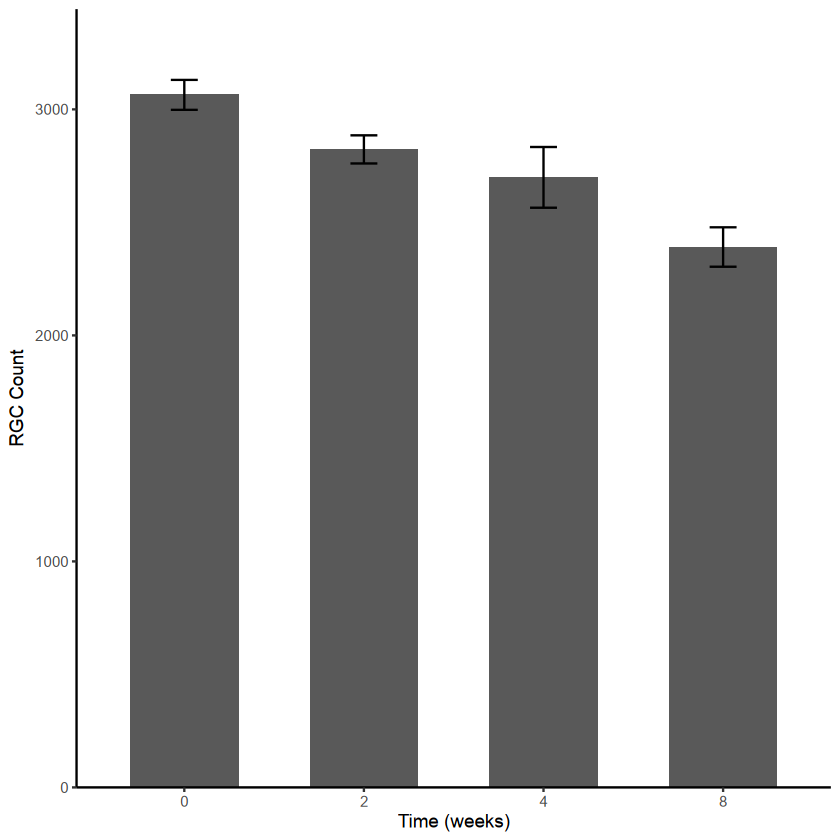

In [7]:
ggplot(df_summary, aes(x = time, y = mean)) +
  geom_col(width = 0.6) +
  geom_errorbar(
    aes(ymin = mean - sem, ymax = mean + sem),
    width = 0.15
  ) + scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  labs(
    x = "Time (weeks)",
    y = "RGC Count"
  ) +
  theme_classic()

In [8]:
model <- lmer(count ~ time + (1 | sample), data = df_sample)
summary(model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: count ~ time + (1 | sample)
   Data: df_sample

REML criterion at convergence: 246.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.11912 -0.36521  0.01957  0.33564  1.23435 

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 31180    176.58  
 Residual              9168     95.75  
Number of obs: 20, groups:  sample, 16

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  3011.39      74.18   16.94  40.598  < 2e-16 ***
time          -80.17      16.75   17.82  -4.785 0.000152 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     (Intr)
time -0.746